# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Setup

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Load dataset (CMAPSS)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Preprocessing

Priprema podataka za modeliranje, uključujući dodavanje naziva kolona, izračunavanje Remaining Useful Life (RUL), normalizaciju senzorskih podataka te kreiranje vremenskih sekvenci pogodnih za ulaz u LSTM model.

In [5]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)]
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [6]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [23]:
train

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,0.477011,0.250000,0.0,0.0,0.686747,0.587312,0.782917,0.0,...,0.558824,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,4
20627,100,197,0.408046,0.083333,0.0,0.0,0.701807,0.729453,0.866475,0.0,...,0.500000,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,3
20628,100,198,0.522989,0.500000,0.0,0.0,0.665663,0.684979,0.775321,0.0,...,0.529412,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,2
20629,100,199,0.436782,0.750000,0.0,0.0,0.608434,0.746021,0.747468,0.0,...,0.514706,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,1


In [8]:
train.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [9]:
test.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni.

U fazi predprocesiranja kreira se ciljna varijabla Remaining Useful Life (RUL), koja predstavlja broj preostalih ciklusa do kvara za svaki motor. Ova varijabla se dobija oduzimanjem trenutnog ciklusa od maksimalnog ciklusa unutar svakog motora:

In [10]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [11]:
train[['engine_id', 'cycle', 'RUL']].head(5)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [12]:
feature_columns = operational_settings + sensor_columns

NORMALIZACIJA:

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [14]:
seq_length = 30

In [15]:
import numpy as np

def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [16]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [17]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ovaj model nema implementirane metode kvantifikacije nesigurnosti, već daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [28]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

In [29]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 6264.9614 - mae: 62.2728 - val_loss: 5452.3096 - val_mae: 58.8791
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3451.4631 - mae: 48.1725 - val_loss: 5346.9238 - val_mae: 58.6868
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3441.4258 - mae: 48.1091 - val_loss: 5392.1694 - val_mae: 58.6689
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3249.1653 - mae: 46.5795 - val_loss: 4341.6377 - val_mae: 50.6526
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1395.7462 - mae: 26.8424 - val_loss: 2508.5125 - val_mae: 33.9904
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1079.9764 - mae: 22.8186 - val_loss: 1768.8889 - val_mae: 28.8834
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 975.2169 - mae: 21.5479 - val_loss: 2098.8672 - val_mae: 29.6682
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 932.8256 - mae: 20.9025 - val_loss: 1930.5869 - val_mae: 

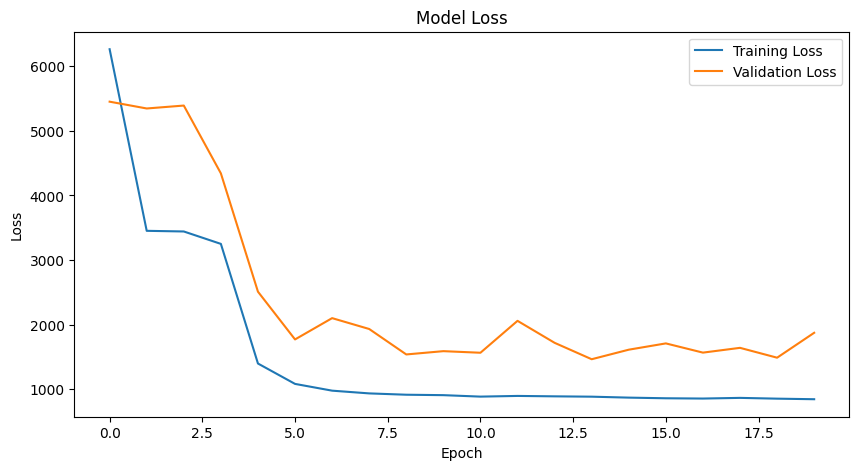

In [31]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [32]:
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [33]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[119.027145]
 [142.30708 ]
 [ 44.95504 ]
 [ 68.53674 ]
 [ 93.39612 ]
 [110.709724]
 [ 95.50213 ]
 [ 84.5328  ]
 [134.71796 ]
 [ 85.7469  ]]


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 21.142878985301632
MAE: 14.374774932861328


## 5. Evaluation

## 6. Uncertainty